In [ ]:
import numpy as np
import imageio.v2 as imio
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier

np.set_printoptions(precision=4, suppress=True)

Si tienes algún error al ejecutar la celda anterior verifica que tu ambiente de anaconda tenga las librerías necesarias.

# Clasificación con K-nearest neighbors
En este notebook vamos a implementar K-nearest neighbors, nuestro algoritmo va a **clasificar** a que raza pertenece la imagen de un perro, para entrenar nuestro algoritmo vamos a utilizar un set de datos contiene imágenes de 120 razas de perros, en total son 10,222 imágenes. No trabajaremos directamente con las imágenes, existe un paso de pre-procesamiento que toma como entrada una imagen y devuelve un vector para la imagen, el vector puede ser considerado un vector de features que describen el contenido de la imagen. No nos preocuparemos de momento  por como se obtiene este vector o calcula exactamente, el pre-procesamiento ya fue dado.

Data: [Dog Breed Identification](https://www.kaggle.com/c/dog-breed-identification/data)

#### Pre-procesamiento

El pre-procesamiento ya fue realizado y el dataset preparado y está listo para usarse, para esto se aplicó un proceso conocido como "transfer learning" usando la red neuronal "Inception" de Google(tema a cubrirse en próximas clases)  , para esta tarea ignoremos este detalle  y pensemos que se nos da un dataset con features donde cada columna representa una característica de entrada importante,pero no nos interesa conocer los detalles. 

Estas features/características fueron almacenadas en un matriz de numpy.

En esta parte del notebook solo hay que ejecutar las celdas para cargar los datos, estos datos van a servir de entrada para nuestra implementación de K-nearest neighbors con tensorflow.

### Referencias opcionales para transfer learning y "Google inception"
##### Inception
https://www.tensorflow.org/tutorials/image_recognition

https://research.googleblog.com/2016/03/train-your-own-image-classifier-with.html

##### Transfer Learning
https://www.datacamp.com/community/tutorials/transfer-learning

In [2]:
images_inception_features = './pre-processing/training_inception_features_array.npy'
training_image_labels_array = './pre-processing/training_image_labels_array.npy'
training_image_names_array = './pre-processing/training_image_names_array.npy'

In [ ]:
TRAIN_DICTIONARY_KEYS = ["images", "label", "features"]

training_set_dict = dict()

# allow_pickle=True es necesario porque los arreglos de labels y nombres contienen objetos/string.
training_set_dict['images_name'] = np.load(training_image_names_array, allow_pickle=True)
training_set_dict['label'] = np.load(training_image_labels_array, allow_pickle=True)
training_set_dict['features'] = np.load(images_inception_features)

#  K-Nearest Neighbors

La data la vamos a manejar en los siguientes 3 arreglos: 

- features    : features de la imagen dadas por google Inception
- labels      : label de la imagen, identifica que raza es
- images_name : nombre de la imagen original, si descargan el dataset con link en la descripción pueden buscar la imagen original por este nombre.

In [4]:
## Cargamos las features y las labes de cada feature
features = training_set_dict['features']
labels = training_set_dict['label']
images_name = training_set_dict['images_name']

In [5]:
len(features)

10222

Las labels pertenecientes a las features tienen el mismo indice, Ejemplo:

Label:  golden_retriever
Nombre:  0021f9ceb3235effd7fcde7f7538ed62


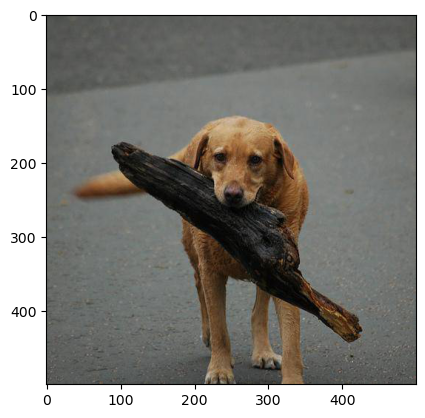

In [ ]:
# Indice 4

print('Label: ',labels[4])

print('Nombre: ',images_name[4])

img = imio.imread('./data/train/'+images_name[4]+'.jpg')
plt.imshow(img)

### Implementa tu codigo de  K-Neighbors aqui:

El siguiente es un ejemplo de como puedes  definir tu función para predecir la raza sobre un punto x_predict ,a través de buscar los "k" vecinos más cercanos en X_train y devolver como predicción el "y" que mas se repite(la moda) correspondiente a esos "k" valores de X_train , este "y" estará dado por Y_train. Debemos usar numpy a pesar de que se presenta un ejemplo de tensorflow.

Un ejemplo  de KNN en tensorflow: http://marubon-ds.blogspot.com/2017/09/knn-k-nearest-neighbors-by-tensorflow.html (este tiene diferencias, usar como guía no copiar literal, por ejemplo este usa una métrica de distancia diferente a la que debemos usar: distancia euclidiana )


#### Instrucciones:
1. Implementar KNN en la función predecir_raza_KNN usando numpy usando distancia euclidiana
2. Ejecutar el modelo con las 2 imágenes de prueba.

#### Tip
Algunas funciones útiles:
* np.sum(): sumar los elementos de un tensor.
* np.sqrt(): calcular la raíz cuadrada de los elementos de un tensor, por ejemplo usada en la fórmula de distancia euclidiana.
* np.argsort(): ordenar los elementos de un tensor y devolver las posiciones ordenadas, por ejemplo para ordenar las distancias.
* collections.Counter(): crear un contador(por ejemplo para contar cuantas ocurrencias hay para cada clase)

In [ ]:
def predecir_raza_KNN(x_predict, X_train, Y_train, k):
    """
    Predice la raza de un perro usando K-Nearest Neighbors con distancia euclidiana.

    Args:
        x_predict (ndarray): vector de features de la imagen a clasificar, shape (n_features,)
        X_train (ndarray): matriz de features de entrenamiento, shape (m, n_features)
        Y_train (ndarray): labels de entrenamiento, shape (m,)
        k (int): número de vecinos más cercanos a considerar

    Returns:
        y (str): label o raza predicha
    """
    if k <= 0:
        raise ValueError("k debe ser un entero positivo.")
    if k > X_train.shape[0]:
        raise ValueError("k no puede ser mayor que la cantidad de ejemplos de entrenamiento.")

    # 1. Calcular distancia euclidiana entre x_predict y cada ejemplo de entrenamiento.
    #    Distancia euclidiana: sqrt(sum((x_train_i - x_predict)^2))
    distances = np.sqrt(np.sum((X_train - x_predict) ** 2, axis=1))

    # 2. Ordenar las distancias y tomar los índices de los k vecinos más cercanos.
    nearest_indices = np.argsort(distances)[:k]

    # 3. Obtener las labels de esos vecinos.
    nearest_labels = Y_train[nearest_indices]

    # 4. Votación por mayoría.
    label_counts = Counter(nearest_labels)
    max_votes = max(label_counts.values())
    tied_labels = {label for label, count in label_counts.items() if count == max_votes}

    # 5. Manejo determinístico de empates:
    #    si hay empate, se escoge la clase del vecino más cercano entre las clases empatadas.
    for label in nearest_labels:
        if label in tied_labels:
            y = label
            break

    return y

## Probamos el algoritmo con nuevas imágenes 

Como buena practica luego de entrenar nuestro algoritmo, lo probamos con imágenes que no ha visto antes 

In [8]:
test_features = np.load('./data/test/test_inception_features_array.npy')

### Prueba 1

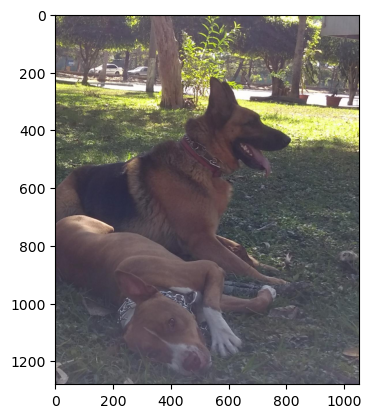

In [9]:
img_test = imio.imread('./data/test/test1.jpg')
plt.imshow(img_test)

In [ ]:
predict_image = test_features[0]

## Ejecuta tu modelo con la entrada de `predict_image`
# Deberíamos obtener: german_shepherd

k = 3
prediccion_test1 = predecir_raza_KNN(predict_image, features, labels, k)

print(f"Predicción para test1.jpg con k={k}: {prediccion_test1}")
assert prediccion_test1 == "german_shepherd", f"Predicción incorrecta: {prediccion_test1}"

print("✅ Correcto: la imagen test1 fue clasificada como german_shepherd.")

Predicción para test1.jpg con k=3: german_shepherd
✅ Correcto: la imagen test1 fue clasificada como german_shepherd.


### Prueba 2

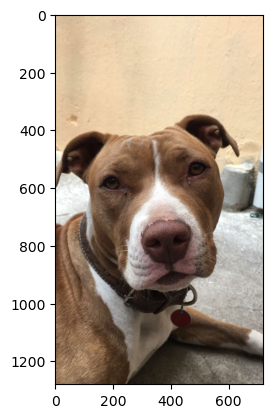

In [11]:
img_test = imio.imread('./data/test/test2.jpg')
plt.imshow(img_test)

In [ ]:
## Ejecuta tu modelo con la entrada de `predict_image`
# Deberíamos obtener: american_staffordshire_terrier

predict_image = test_features[1]

k = 3
prediccion_test2 = predecir_raza_KNN(predict_image, features, labels, k)

print(f"Predicción para test2.jpg con k={k}: {prediccion_test2}")
assert prediccion_test2 == "american_staffordshire_terrier", f"Predicción incorrecta: {prediccion_test2}"

print("✅ Correcto: la imagen test2 fue clasificada como american_staffordshire_terrier.")

Predicción para test2.jpg con k=3: american_staffordshire_terrier
✅ Correcto: la imagen test2 fue clasificada como american_staffordshire_terrier.


### Implementa knn con sklearn para comparar tu implementación:

En esta sección utilizarás los mismos datos y realizarás el mismo proceso pero con la implementación de knn existente en sklearn: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html. Acá se da un ejemplo de knn usando sklearn(para datos ficticios dados), debemos usar código similar pero con el dataset de razas de perros

In [ ]:
# Implementación equivalente con sklearn para comparar contra nuestra función manual.

k = 3

knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
knn_sklearn.fit(features, labels)

predicciones_sklearn = knn_sklearn.predict(test_features)

print("Predicciones con sklearn:")
print(f"  test1.jpg → {predicciones_sklearn[0]}")
print(f"  test2.jpg → {predicciones_sklearn[1]}")

print("\nPredicciones con nuestra implementación:")
print(f"  test1.jpg → {prediccion_test1}")
print(f"  test2.jpg → {prediccion_test2}")

assert predicciones_sklearn[0] == prediccion_test1
assert predicciones_sklearn[1] == prediccion_test2

print("\n✅ Correcto: sklearn y la implementación manual producen las mismas predicciones.")

Predicciones con sklearn:
  test1.jpg → german_shepherd
  test2.jpg → american_staffordshire_terrier

Predicciones con nuestra implementación:
  test1.jpg → german_shepherd
  test2.jpg → american_staffordshire_terrier

✅ Correcto: sklearn y la implementación manual producen las mismas predicciones.
